<a href="https://colab.research.google.com/github/HaroldSthid/CodeLabSIG_Unisabana/blob/main/Pixel_Programing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Step 1 Mapeo origen fuente de datos

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Step 2 Importanto librerias

Aquí, importamos Image de PIL para trabajar con la imagen, openpyxl para manipular archivos de Excel y PatternFill para aplicar colores a las celdas de Excel.

In [ ]:
# Importar las bibliotecas necesarias
from PIL import Image
import openpyxl
from openpyxl.styles import PatternFill

# Step 3 Funcion para procesar Imagen

Esta línea define la función image_to_excel con tres argumentos: image_path (ruta de la imagen JPG), excel_path (ruta del archivo Excel a guardar) y scale (factor de escala para la imagen, por defecto es 1, es decir, sin cambio de escala).

In [ ]:
# Función para procesar la imagen
def procesar_imagen(ruta_imagen, tamano_maximo):
    # Cargar la imagen y redimensionar si es necesario
    with Image.open(ruta_imagen) as img:
        img.thumbnail(tamano_maximo)  # Redimensionar la imagen
        pixeles = list(img.getdata())  # Obtener los datos de los píxeles
        ancho, alto = img.size         # Obtener las dimensiones de la imagen
    return pixeles, ancho, alto       # Devolver los píxeles y dimensiones

In [ ]:
# Función para crear y llenar la hoja de Excel
def crear_hoja_excel(pixeles, ancho, alto):
    wb = openpyxl.Workbook()          # Crear un nuevo libro de trabajo
    hoja = wb.active                  # Obtener la hoja activa

    # Recorrer los píxeles y aplicar el color a cada celda
    for y in range(alto):
        for x in range(ancho):
            color = pixeles[x + y * ancho]                       # Obtener el color RGB
            color_hex = f"{color[0]:02x}{color[1]:02x}{color[2]:02x}"  # Convertir a hex
            celda = hoja.cell(row=y + 1, column=x + 1)           # Obtener la celda
            celda.fill = PatternFill(start_color=color_hex, end_color=color_hex, fill_type="solid")

    return wb  # Devolver el libro de trabajo

# Función principal
def main():
    # Actualiza esta ruta a la ubicación de tu imagen en Google Drive
    ruta_imagen = "/content/drive/MyDrive/SIG/Owala.jpg"  # Ejemplo: "/content/drive/My Drive/Images/mi_imagen.jpg"
    tamano_maximo = (50, 50)

    pixeles, ancho, alto = procesar_imagen(ruta_imagen, tamano_maximo)
    wb = crear_hoja_excel(pixeles, ancho, alto)

    # Guardar el archivo de Excel en Google Drive
    ruta_guardado = "/content/drive/MyDrive/SIG/Pixel_foto2.jpg_v1.xlsx"  # Ejemplo: "/content/drive/My Drive/ExcelFiles/imagen_excel.xlsx"
    wb.save(ruta_guardado)

if __name__ == "__main__":
    main()


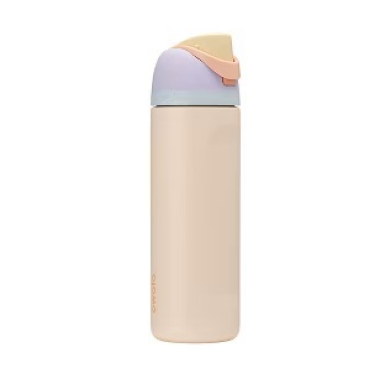

In [ ]:
# prompt: quiero plotear la imagen que acabamos de procesar

from PIL import Image
import matplotlib.pyplot as plt

def mostrar_imagen(ruta_imagen):
    try:
        img = Image.open(ruta_imagen)
        plt.imshow(img)
        plt.axis('off')  # Ocultar ejes
        plt.show()
    except FileNotFoundError:
        print(f"Error: Archivo no encontrado en {ruta_imagen}")
    except Exception as e:
        print(f"Error al mostrar la imagen: {e}")

# Ejemplo de uso (reemplaza con la ruta correcta de tu imagen)
ruta_imagen = "/content/drive/MyDrive/SIG/Owala.jpg"
mostrar_imagen(ruta_imagen)


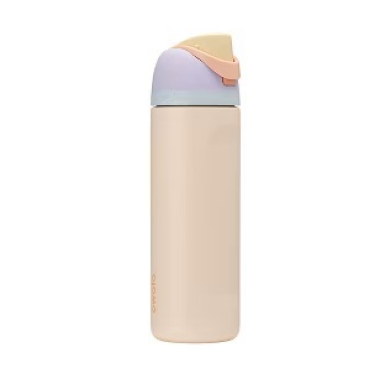

In [ ]:
# prompt: ahora quiero ver esta imagen en Pixeles que representa el output de nuestro scritp

import matplotlib.pyplot as plt
def mostrar_imagen(ruta_imagen):
    try:
        img = Image.open(ruta_imagen)
        plt.imshow(img)
        plt.axis('off')  # Ocultar ejes
        plt.show()
    except FileNotFoundError:
        print(f"Error: Archivo no encontrado en {ruta_imagen}")
    except Exception as e:
        print(f"Error al mostrar la imagen: {e}")

# Ejemplo de uso (reemplaza con la ruta correcta de tu imagen)
ruta_imagen = "/content/drive/MyDrive/SIG/Owala.jpg"
mostrar_imagen(ruta_imagen)


In [ ]:
import openpyxl

def read_excel_colors(excel_path):
    """
    Reads an Excel file, extracts RGB color codes (from cell values or fill colors)
    from its cells, and returns a 2D list (matrix) of these color values.

    Args:
        excel_path (str): The path to the input Excel file.

    Returns:
        list[list[str]]: A 2D list (matrix) where each inner list represents a row
                         and contains hexadecimal color codes for each cell.
    """
    try:
        # Load the workbook from excel_path
        wb = openpyxl.load_workbook(excel_path)
        # Get the active worksheet from the loaded workbook
        ws = wb.active

        # Initialize an empty list of lists to store the extracted hex color codes
        colors_matrix = []

        # Iterate through each row in the worksheet
        for row in ws.iter_rows():
            row_colors = []
            # For each cell in the current row, get its color
            for cell in row:
                hex_color = 'FFFFFF' # Default to white if no color is found or parsed

                # Attempt to parse color from cell value first
                if cell.value is not None:
                    cell_value_str = str(cell.value).strip()

                    # Case 1: "R, G, B" or "R G B" format
                    if ',' in cell_value_str:
                        try:
                            r, g, b = map(int, cell_value_str.replace(' ', '').split(','))
                            if 0 <= r <= 255 and 0 <= g <= 255 and 0 <= b <= 255:
                                hex_color = f"{r:02x}{g:02x}{b:02x}".upper()
                            else:
                                print(f"Warning: RGB values out of range in cell {cell.coordinate}: {cell_value_str}")
                        except ValueError:
                            pass # Not a valid "R, G, B" string
                    # Case 2: Hex string (e.g., 'FF0000' or '000000')
                    elif len(cell_value_str) == 6 and all(c in '0123456789ABCDEFabcdef' for c in cell_value_str):
                        hex_color = cell_value_str.upper()

                # Fallback: Check for existing cell fill color if value parsing failed or was empty
                if hex_color == 'FFFFFF' and cell.fill and cell.fill.start_color and cell.fill.start_color.rgb:
                    # Extract the RGB part (last 6 characters) from 'FFRRGGBB' or 'AARRGGBB'
                    hex_color = cell.fill.start_color.rgb[-6:].upper()

                row_colors.append(hex_color)
            # After processing all cells in a row, append row_colors to colors_matrix
            colors_matrix.append(row_colors)

        return colors_matrix
    except FileNotFoundError:
        print(f"Error: El archivo no fue encontrado en la ruta: {excel_path}")
        return None
    except Exception as e:
        print(f"Ocurrió un error al leer el archivo Excel: {e}")
        return None

print("The 'read_excel_colors' function has been defined.")

The 'read_excel_colors' function has been defined.


In [ ]:
import openpyxl
from openpyxl.styles import PatternFill

def write_colors_to_excel(colors_matrix, output_excel_path):
    """
    Creates a new Excel file and fills its cells with the specified hexadecimal color codes.

    Args:
        colors_matrix (list[list[str]]): A 2D list (matrix) of hexadecimal color codes.
        output_excel_path (str): The path where the new Excel file will be saved.
    """
    try:
        wb = openpyxl.Workbook()  # Create a new workbook
        ws = wb.active            # Get the active worksheet

        # Iterate through the colors_matrix to fill cells
        for r_idx, row_colors in enumerate(colors_matrix):
            for c_idx, hex_color in enumerate(row_colors):
                # Ensure hex_color is a valid 6-digit hex string
                if hex_color and len(hex_color) == 6:
                    fill = PatternFill(start_color=hex_color, end_color=hex_color, fill_type="solid")
                    cell = ws.cell(row=r_idx + 1, column=c_idx + 1)
                    cell.fill = fill
                else:
                    # Optionally, handle invalid hex codes (e.g., set to white or skip)
                    pass

        # Adjust column widths and row heights for better visualization if needed
        # For simplicity, we'll skip complex auto-sizing here, but it could be added.
        # For example, to make cells square-ish for 'pixel art':
        # for col_idx in range(1, ws.max_column + 1):
        #     ws.column_dimensions[openpyxl.utils.get_column_letter(col_idx)].width = 2
        # for row_idx in range(1, ws.max_row + 1):
        #     ws.row_dimensions[row_idx].height = 12 # Roughly corresponds to width=2

        wb.save(output_excel_path) # Save the workbook
        print(f"Successfully created Excel file at: {output_excel_path}")
    except Exception as e:
        print(f"Error al escribir el archivo Excel: {e}")

print("The 'write_colors_to_excel' function has been defined.")

The 'write_colors_to_excel' function has been defined.


In [ ]:
from google.colab import drive
import os

# Mount Google Drive if not already mounted
drive.mount('/content/drive')

# --- Define example usage ---

# IMPORTANT: Replace these paths with your actual input and desired output file paths
# Example input Excel file with hex color codes in cells
input_excel_path = '/content/drive/MyDrive/SIG/imagen_excel_v2.xlsx'
# Example output Excel file where colored cells will be saved
output_excel_path = '/content/drive/MyDrive/SIG/imagen_excel_v2.xlsx'

print(f"Attempting to read colors from: {input_excel_path}")
if not os.path.exists(input_excel_path):
    print(f"Error: Input file not found at {input_excel_path}. Please ensure the path is correct and the file exists.")
else:
    # 1. Read colors from the input Excel file
    colors_data = read_excel_colors(input_excel_path)

    if colors_data:
        print(f"Successfully read {len(colors_data)} rows of color data.")
        # 2. Write the colors to a new Excel file
        write_colors_to_excel(colors_data, output_excel_path)
    else:
        print("Failed to read color data from the input Excel file.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Attempting to read colors from: /content/drive/MyDrive/SIG/imagen_excel_v2.xlsx
Error: Input file not found at /content/drive/MyDrive/SIG/imagen_excel_v2.xlsx. Please ensure the path is correct and the file exists.


### Generando una Matriz RGB de 'foto2.jpg' en Excel

In [14]:
# Asegúrate de que las funciones 'procesar_imagen' y 'crear_hoja_excel' estén definidas y ejecutadas previamente.
# Por simplicidad, este bloque asume que ya están en el entorno.

# Ruta de la imagen 'foto2.jpg' en Google Drive
ruta_imagen_foto2 = "/content/drive/MyDrive/SIG/spiderman.jpg"

# Ruta donde se guardará el nuevo archivo Excel
ruta_guardado_excel = "/content/drive/MyDrive/SIG/Matriz_RGB_foto2.xlsx"

# Define el tamaño máximo para la imagen (esto determinará el número de celdas en Excel)
tamano_maximo_para_excel = (100, 100) # Por ejemplo, 100x100 píxeles

# 1. Procesar la imagen
pixeles_foto2, ancho_foto2, alto_foto2 = procesar_imagen(ruta_imagen_foto2, tamano_maximo_para_excel)

if pixeles_foto2 is None:
    print(f"No se pudo procesar la imagen: {ruta_imagen_foto2}. Verifica la ruta y el formato.")
else:
    print(f"Imagen procesada: {ancho_foto2}x{alto_foto2} píxeles.")

    # 2. Crear y llenar el libro de Excel con los píxeles de la imagen
    wb_foto2 = crear_hoja_excel(pixeles_foto2, ancho_foto2, alto_foto2)

    # 3. Guardar el archivo Excel
    try:
        wb_foto2.save(ruta_guardado_excel)
        print(f"Matriz RGB de la imagen 'foto2.jpg' guardada exitosamente en: {ruta_guardado_excel}")
    except Exception as e:
        print(f"Error al guardar el archivo Excel: {e}")

Imagen procesada: 97x100 píxeles.
Matriz RGB de la imagen 'foto2.jpg' guardada exitosamente en: /content/drive/MyDrive/SIG/Matriz_RGB_foto2.xlsx


### Convirtiendo la Matriz Numérica RGB de Excel a Imagen

In [15]:
import openpyxl
from PIL import Image
import matplotlib.pyplot as plt

def excel_to_image(excel_path, output_image_path):
    """
    Lee una matriz RGB numérica desde un archivo Excel y la convierte de nuevo en una imagen.

    Args:
        excel_path (str): La ruta al archivo Excel que contiene los valores RGB numéricos (ej. 'R,G,B').
        output_image_path (str): La ruta donde se guardará la imagen reconstruida.
    """
    try:
        wb = openpyxl.load_workbook(excel_path)
        ws = wb.active

        pixels_data = []
        height = 0
        width = 0

        # Leer los valores RGB de las celdas y determinar las dimensiones
        for row_idx, row in enumerate(ws.iter_rows()):
            current_row_pixels = []
            for col_idx, cell in enumerate(row):
                if cell.value:
                    try:
                        r, g, b = map(int, str(cell.value).split(','))
                        current_row_pixels.append((r, g, b))
                        if col_idx + 1 > width: # Asegurarse de capturar el ancho máximo
                            width = col_idx + 1
                    except ValueError:
                        # Si la celda no contiene 'R,G,B' válido, usar blanco por defecto
                        current_row_pixels.append((255, 255, 255))
                else:
                    current_row_pixels.append((255, 255, 255)) # Celda vacía, usar blanco

            if current_row_pixels: # Solo añadir filas con datos
                pixels_data.append(current_row_pixels)
                height += 1

        # Reconstruir la lista plana de píxeles para PIL
        flat_pixels = [pixel for row_pixels in pixels_data for pixel in row_pixels]

        if not flat_pixels or width == 0 or height == 0:
            print("Error: No se pudieron extraer datos de píxeles válidos del archivo Excel.")
            return

        # Crear una nueva imagen PIL
        img = Image.new('RGB', (width, height))
        img.putdata(flat_pixels)

        # Guardar la imagen
        img.save(output_image_path)
        print(f"Imagen reconstruida guardada exitosamente en: {output_image_path}")

        # Opcional: Mostrar la imagen
        plt.imshow(img)
        plt.axis('off')
        plt.title('Imagen Reconstruida desde Excel')
        plt.show()

    except FileNotFoundError:
        print(f"Error: El archivo Excel no se encontró en la ruta: {excel_path}")
    except Exception as e:
        print(f"Ocurrió un error al convertir el Excel a imagen: {e}")

# --- Uso de la función ---

# Ruta del archivo Excel numérico que creamos antes
excel_input_path = "/content/drive/MyDrive/SIG/Matriz_RGB_Numerica_foto2.xlsx"

# Ruta donde se guardará la imagen reconstruida
image_output_path = "/content/drive/MyDrive/SIG/Imagen_Reconstruida_foto2.png"

print(f"Convirtiendo {excel_input_path} a imagen...")
excel_to_image(excel_input_path, image_output_path)

Convirtiendo /content/drive/MyDrive/SIG/Matriz_RGB_Numerica_foto2.xlsx a imagen...
Error: El archivo Excel no se encontró en la ruta: /content/drive/MyDrive/SIG/Matriz_RGB_Numerica_foto2.xlsx


### Regenerando la Matriz Numérica RGB de 'foto2.jpg' en Excel (Petición del Usuario)

In [16]:
from google.colab import drive
from PIL import Image
import openpyxl
from openpyxl.styles import PatternFill
import os

drive.mount('/content/drive', force_remount=True) # Asegurarse de que Drive esté montado

# Asegúrate de que la función 'procesar_imagen' esté definida, o la definimos aquí para este bloque
# Si ya la tienes definida en otra celda y ejecutada, puedes comentar esta parte.
def procesar_imagen(ruta_imagen, tamano_maximo=None):
    try:
        with Image.open(ruta_imagen) as img:
            if tamano_maximo:
                img.thumbnail(tamano_maximo)  # Redimensionar la imagen si se proporciona un tamaño máximo
            pixeles = list(img.getdata())  # Obtener los datos de los píxeles
            ancho, alto = img.size         # Obtener las dimensiones de la imagen
        return pixeles, ancho, alto       # Devolver los píxeles y dimensiones
    except Exception as e:
        print(f"Error al procesar la imagen: {e}")
        return None, None, None

# Nueva función para crear y llenar la hoja de Excel con los valores RGB como números
def crear_hoja_excel_numerica(pixeles, ancho, alto):
    wb = openpyxl.Workbook()          # Crear un nuevo libro de trabajo
    hoja = wb.active                  # Obtener la hoja activa

    # Recorrer los píxeles y escribir el valor RGB en cada celda
    for y in range(alto):
        for x in range(ancho):
            color = pixeles[x + y * ancho]                       # Obtener el color RGB (tupla)
            # Escribir el valor RGB en la celda como una cadena "R,G,B"
            hoja.cell(row=y + 1, column=x + 1).value = f"{color[0]},{color[1]},{color[2]}"
            # También puedes aplicar un color de fondo si lo deseas (descomenta para activar)
            # color_hex = f"{color[0]:02x}{color[1]:02x}{color[2]:02x}"
            # hoja.cell(row=y + 1, column=x + 1).fill = PatternFill(start_color=color_hex, end_color=color_hex, fill_type="solid")

    return wb  # Devolver el libro de trabajo

# --- Uso de la nueva función para 'foto2.jpg' ---

# Ruta de la imagen 'foto2.jpg' en Google Drive
ruta_imagen_foto2_regenerada = "/content/drive/MyDrive/SIG/foto2.jpg"

# Ruta donde se guardará el nuevo archivo Excel con valores numéricos
ruta_guardado_excel_numerico_regenerado = "/content/drive/MyDrive/SIG/Matriz_RGB_Numerica_foto2.xlsx"

# Define el tamaño máximo para la imagen (esto determinará el número de celdas en Excel)
tamano_maximo_para_excel_regenerado = (50, 50) # Reducido para un archivo más manejable

print(f"Procesando imagen: {ruta_imagen_foto2_regenerada} a un tamaño máximo de {tamano_maximo_para_excel_regenerado} píxeles...")

# 1. Procesar la imagen para obtener píxeles
pixeles_foto2_num_regenerado, ancho_foto2_num_regenerado, alto_foto2_num_regenerado = procesar_imagen(ruta_imagen_foto2_regenerada, tamano_maximo_para_excel_regenerado)

if pixeles_foto2_num_regenerado is None:
    print(f"No se pudo procesar la imagen: {ruta_imagen_foto2_regenerada}. Verifica la ruta y el formato.")
else:
    print(f"Imagen procesada: {ancho_foto2_num_regenerado}x{alto_foto2_num_regenerado} píxeles.")

    # 2. Crear y llenar el libro de Excel con los píxeles de la imagen (valores numéricos)
    wb_foto2_num_regenerado = crear_hoja_excel_numerica(pixeles_foto2_num_regenerado, ancho_foto2_num_regenerado, alto_foto2_num_regenerado)

    # 3. Guardar el archivo Excel
    try:
        wb_foto2_num_regenerado.save(ruta_guardado_excel_numerico_regenerado)
        print(f"Matriz RGB numérica de la imagen 'foto2.jpg' guardada exitosamente en: {ruta_guardado_excel_numerico_regenerado}")
    except Exception as e:
        print(f"Error al guardar el archivo Excel numérico: {e}")

Mounted at /content/drive
Procesando imagen: /content/drive/MyDrive/SIG/foto2.jpg a un tamaño máximo de (50, 50) píxeles...
Error al procesar la imagen: [Errno 2] No such file or directory: '/content/drive/MyDrive/SIG/foto2.jpg'
No se pudo procesar la imagen: /content/drive/MyDrive/SIG/foto2.jpg. Verifica la ruta y el formato.


In [17]:
import os
from google.colab import drive

drive.mount('/content/drive', force_remount=True) # Asegurarse de que Drive esté montado

ruta_guardado_excel_numerico = "/content/drive/MyDrive/SIG/Matriz_RGB_Numerica_foto2.xlsx"

if os.path.exists(ruta_guardado_excel_numerico):
    print(f"¡Confirmado! El archivo se encuentra en: {ruta_guardado_excel_numerico}")
    print("Por favor, revisa esta ruta en tu Google Drive.")
else:
    print(f"Lo siento, el archivo NO se encontró en la ruta esperada: {ruta_guardado_excel_numerico}")
    print("Asegúrate de haber ejecutado las celdas de código que crean la matriz numérica.")

Mounted at /content/drive
Lo siento, el archivo NO se encontró en la ruta esperada: /content/drive/MyDrive/SIG/Matriz_RGB_Numerica_foto2.xlsx
Asegúrate de haber ejecutado las celdas de código que crean la matriz numérica.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


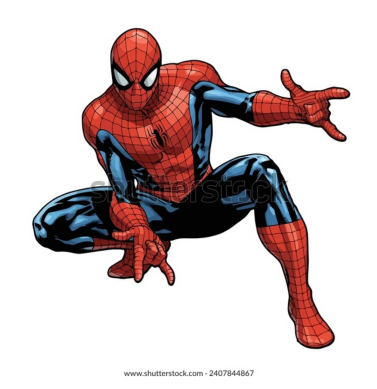

In [26]:
# prompt: como puedo tener un resultado con menos pixeles?

from google.colab import drive
from PIL import Image
import openpyxl
from openpyxl.styles import PatternFill
import matplotlib.pyplot as plt

# Mount Google Drive
drive.mount('/content/drive')

def procesar_imagen(ruta_imagen, tamano_maximo):
    with Image.open(ruta_imagen) as img:
        img.thumbnail(tamano_maximo)
        pixeles = list(img.getdata())
        ancho, alto = img.size
    return pixeles, ancho, alto

def crear_hoja_excel(pixeles, ancho, alto):
    wb = openpyxl.Workbook()
    hoja = wb.active
    for y in range(alto):
        for x in range(ancho):
            color = pixeles[x + y * ancho]
            color_hex = f"{color[0]:02x}{color[1]:02x}{color[2]:02x}"
            celda = hoja.cell(row=y + 1, column=x + 1)
            celda.fill = PatternFill(start_color=color_hex, end_color=color_hex, fill_type="solid")
    return wb

def main():
    ruta_imagen = "/content/drive/MyDrive/SIG/spiderman.jpg"
    # Reduce the size for fewer pixels in the output Excel file
    tamano_maximo = (20, 20)  # Example: 20x20 pixels

    pixeles, ancho, alto = procesar_imagen(ruta_imagen, tamano_maximo)
    wb = crear_hoja_excel(pixeles, ancho, alto)

    ruta_guardado = "/content/drive/MyDrive/SIG/Pixel_Flash_v1_small.xlsx"
    wb.save(ruta_guardado)

if __name__ == "__main__":
    main()

def mostrar_imagen(ruta_imagen):
    try:
        img = Image.open(ruta_imagen)
        plt.imshow(img)
        plt.axis('off')
        plt.show()
    except FileNotFoundError:
        print(f"Error: Archivo no encontrado en {ruta_imagen}")
    except Exception as e:
        print(f"Error al mostrar la imagen: {e}")

ruta_imagen = "/content/drive/MyDrive/SIG/spiderman.jpg"
mostrar_imagen(ruta_imagen)


In [28]:
# Step 1 Mapeo origen fuente de datos
from google.colab import drive
drive.mount('/content/drive')

# Step 2 Importando librerías
from PIL import Image
import openpyxl
from openpyxl.styles import PatternFill
import os

# Función para procesar la imagen
def procesar_imagen(ruta_imagen, tamano_maximo=None):
    try:
        with Image.open(ruta_imagen) as img:
            if tamano_maximo:
                img.thumbnail(tamano_maximo)  # Redimensionar la imagen si se proporciona un tamaño máximo
            pixeles = list(img.getdata())  # Obtener los datos de los píxeles
            ancho, alto = img.size         # Obtener las dimensiones de la imagen
        return pixeles, ancho, alto       # Devolver los píxeles y dimensiones
    except Exception as e:
        print(f"Error al procesar la imagen: {e}")
        return None, None, None

# Función para crear y llenar la hoja de Excel
def crear_hoja_excel(pixeles, ancho, alto):
    wb = openpyxl.Workbook()          # Crear un nuevo libro de trabajo
    hoja = wb.active                  # Obtener la hoja activa

    # Recorrer los píxeles y aplicar el color a cada celda
    for y in range(alto):
        for x in range(ancho):
            color = pixeles[x + y * ancho]                       # Obtener el color RGB
            color_hex = f"{color[0]:02x}{color[1]:02x}{color[2]:02x}"  # Convertir a hex
            celda = hoja.cell(row=y + 1, column=x + 1)           # Obtener la celda
            celda.fill = PatternFill(start_color=color_hex, end_color=color_hex, fill_type="solid")

    return wb  # Devolver el libro de trabajo

# Función principal
def main():
    ruta_imagen = "/content/drive/MyDrive/SIG/spiderman.jpg"

    if not os.path.exists(ruta_imagen):
        print(f"Imagen no encontrada: {ruta_imagen}")
        return

    # Ajustar el tamaño máximo para que la imagen no exceda los límites de Excel
    tamano_maximo = (200, 200)  # Puedes ajustar este tamaño según sea necesario

    pixeles, ancho, alto = procesar_imagen(ruta_imagen, tamano_maximo)

    if pixeles is None:
        print("No se pudo procesar la imagen.")
        return

    wb = crear_hoja_excel(pixeles, ancho, alto)

    ruta_guardado = "/content/drive/MyDrive/SIG/Pixel_Flash_v3.xlsx"

    try:
        wb.save(ruta_guardado)
        print(f"Archivo Excel guardado exitosamente en: {ruta_guardado}")
    except Exception as e:
        print(f"Error al guardar el archivo Excel: {e}")

if __name__ == "__main__":
    main()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Archivo Excel guardado exitosamente en: /content/drive/MyDrive/SIG/Pixel_Flash_v3.xlsx


#SEGUNDA ITERACION

In [22]:
from PIL import Image
import openpyxl
from openpyxl.styles import PatternFill

In [23]:
def image_to_excel(image_path, excel_path, scale=1):
    # Cargar la imagen y escalar si es necesario
    img = Image.open(image_path)
    if scale != 1:
        img = img.resize((int(img.width * scale), int(img.height * scale)))

    img_rgb = img.convert('RGB')

    # Crear un nuevo archivo Excel
    wb = openpyxl.Workbook()
    ws = wb.active

    # Calcular dimensiones óptimas de las celdas basadas en la relación de aspecto de la imagen
    max_dim = 100  # Máxima dimensión para evitar celdas excesivamente grandes
    cell_width = max_dim / img.width
    cell_height = max_dim / img.height

    # Iterar sobre cada píxel de la imagen
    for i in range(img.width):
        for j in range(img.height):
            r, g, b = img_rgb.getpixel((i, j))
            hex_color = f"{r:02x}{g:02x}{b:02x}"
            fill = PatternFill(start_color=hex_color, end_color=hex_color, fill_type="solid")

            # Asignar el color al fondo de la celda correspondiente
            cell = ws.cell(row=j + 1, column=i + 1)
            cell.fill = fill

        # Ajustar el tamaño de las columnas y filas
        ws.column_dimensions[openpyxl.utils.get_column_letter(i+1)].width = cell_width
        for j in range(img.height):
            ws.row_dimensions[j+1].height = cell_height

    # Guardar el archivo Excel
    wb.save(excel_path)



In [1]:
# Uso de la función con escala opcional
image_path = '/content/drive/MyDrive/SIG/'  # Reemplazar con la ruta a tu imagen
excel_path = '/content/drive/MyDrive/SIG/excel.xlsx'  # Reemplazar con la ruta donde quieres guardar el Excel
scale = 0.5  # Escalar la imagen a la mitad de su tamaño original
image_to_excel(image_path, excel_path, scale)

NameError: name 'image_to_excel' is not defined